### IMPORTS

In [1]:
import warnings
# Ignore all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

import re
import math
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.svm import SVC
import random
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

# Make results reproducible
random.seed(100)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\UFC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Load Data

In [2]:
# Labelled data loading
data = pd.read_csv('A2_customer_churn_labeled.csv')
data.head()

,ID,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,customer_profile,Y
0,0,585,4,0.00,2,0,1,101728.46,This customer is a 44-year-old female from Spa...,0
1,1,743,6,140348.56,2,1,1,163254.39,This customer is a 32-year-old female from Ger...,0
2,2,527,10,136733.23,1,1,1,57589.29,This customer is a 41-year-old female from Ger...,0
3,3,732,6,98792.40,1,1,0,81491.70,This customer is a 45-year-old female from Ger...,1
4,4,641,3,0.00,2,1,0,116466.19,This customer is a 38-year-old female from Fra...,0


In [3]:
print('Shape of labeled data: ', data.shape)

Shape of labeled data:  (7000, 10)


### Helper functions for adding new columns 

In [4]:
def get_last_two_sentences(text):
    sentences = sent_tokenize(text)

    # Get the last 2 sentences
    last_two_sentences = sentences[-2:]

    return ' '.join(last_two_sentences)

# Create an object instance sih of SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Function that returns compound polarity score of the text
def get_polarity(text):
    # Get the polarity scores of the passed text
    return sia.polarity_scores(text)['compound']

# Load spaCy's English tokenizer and tagger
nlp = spacy.load("en_core_web_sm")

# Define a function to perform tokenization, stopwords removal, and lemmatization
def preprocess_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.text.lower() not in STOP_WORDS]
    return " ".join(tokens)


### Add new columns

In [5]:
def add_new_columns(dataset):
     #  Just comment the line for the column that is not needed
    
    dataset['age'] = dataset['customer_profile'].apply(lambda x: int(re.findall('(\d+)-year-old', x)[0]))
    dataset['gender'] = dataset['customer_profile'].apply(lambda x: re.findall('(male|female)', x)[0])
    dataset['country'] = dataset['customer_profile'].apply(lambda x: re.findall('from (\w+)', x)[0])
    dataset['last_lines'] = dataset['customer_profile'].apply(lambda text: get_last_two_sentences(text))
    dataset['customer_profile_polarity'] = dataset['customer_profile'].apply(lambda text: get_polarity(text))
    dataset['last_lines_polarity'] = dataset['last_lines'].apply(lambda text: get_polarity(text))
    dataset['customer_profile_tokenized'] = dataset['customer_profile'].apply(lambda text: preprocess_text(text))
    return dataset

In [6]:
data1 = add_new_columns(data)

### Drop any existing columns

In [7]:
def drop_any_existing_columns(dataset, columns = ['ID']):
    dataset = dataset.drop(columns=columns, inplace=False)
    return dataset

In [8]:
columns_to_drop = ['ID', 'customer_profile', 'last_lines', 'customer_profile_tokenized']

data2 = drop_any_existing_columns(data1, columns = columns_to_drop)

### Any required feature transformations

In [9]:
data2.head()

,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,Y,age,gender,country,customer_profile_polarity,last_lines_polarity
0,585,4,0.00,2,0,1,101728.46,0,44,female,Spain,0.7311,0.4512
1,743,6,140348.56,2,1,1,163254.39,0,32,female,Germany,0.7845,0.6486
2,527,10,136733.23,1,1,1,57589.29,0,41,female,Germany,0.7845,0.6486
3,732,6,98792.40,1,1,0,81491.70,1,45,female,Germany,0.4482,-0.3089
4,641,3,0.00,2,1,0,116466.19,0,38,female,France,0.4482,-0.3089


In [10]:
### Dummy variablize
data3 = pd.get_dummies(data2, columns = ['gender', 'country'], drop_first=True )
print(data3.columns)
data3.head()

Index(['credit_score', 'tenure', 'balance', 'number_of_products',
       'has_credit_card', 'is_active_member', 'salary', 'Y', 'age',
       'customer_profile_polarity', 'last_lines_polarity', 'gender_male',
       'country_Germany', 'country_Spain'],
      dtype='object')


,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,Y,age,customer_profile_polarity,last_lines_polarity,gender_male,country_Germany,country_Spain
0,585,4,0.00,2,0,1,101728.46,0,44,0.7311,0.4512,False,False,True
1,743,6,140348.56,2,1,1,163254.39,0,32,0.7845,0.6486,False,True,False
2,527,10,136733.23,1,1,1,57589.29,0,41,0.7845,0.6486,False,True,False
3,732,6,98792.40,1,1,0,81491.70,1,45,0.4482,-0.3089,False,True,False
4,641,3,0.00,2,1,0,116466.19,0,38,0.4482,-0.3089,False,False,False


## Models implementation

### Model evaluation metrics

In [11]:
def calc_f1_score(model, X=None, y=None, dataset=None, type='macro'):
    if X is None and y is None and dataset is not None:
        y = dataset['Y']
        X = dataset.drop(columns='Y')
    y_pred = model.predict(X)
    return f1_score(y, y_pred, average='macro')

### Model 1 Gradient Boosting Basic

In [12]:
# Perform train test split
X_train, X_test, y_train, y_test = train_test_split(data3.drop(columns='Y'), data3['Y'], test_size=0.2, random_state=42)

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

boost_classifier = GradientBoostingClassifier(n_estimators=1000, random_state=42, learning_rate=0.25)

# Fit the model to the training data
boost_classifier.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.25, n_estimators=1000,
                           random_state=42)

In [31]:
calc_f1_score(boost_classifier, X=X_test, y=y_test)

0.8799957598671424

In [32]:
boost_classifier.fit(data3.drop(columns='Y'), data3['Y'])

GradientBoostingClassifier(learning_rate=0.25, n_estimators=1000,
                           random_state=42)

## Sampling Smote

In [24]:
from imblearn.over_sampling import SMOTE
import pandas as pd

def sampling_methods(X,sampling_method,sampling_ratio = None):
    
    minority_class_label = 1
    
    if sampling_method == 'over':

        minority_samples = X[X['Y'] == minority_class_label]
        majority_samples = X[X['Y'] != minority_class_label]
        
        if sampling_ratio == None:
            ratio = len(majority_samples) // len(minority_samples)
        else:
            ratio = sampling_ratio
        oversampled_minority = minority_samples.sample(n=len(minority_samples) * (ratio), replace=True)

        df = pd.concat([majority_samples, oversampled_minority], ignore_index=True)
    
    elif sampling_method == 'under':

        minority_samples = X[X['Y'] == minority_class_label]
        majority_samples = X[X['Y'] != minority_class_label]

        if sampling_ratio == None:
            ratio = len(minority_samples) / len(majority_samples)
        else:
            ratio = sampling_ratio
        
        undersampled_majority = majority_samples.sample(frac=ratio, random_state= 42)

        df = pd.concat([minority_samples, undersampled_majority], ignore_index=True)
    
    elif sampling_method == 'SMOTE':
        
        minority_samples = X[X['Y'] == minority_class_label]
        majority_samples = X[X['Y'] != minority_class_label]

        if sampling_ratio == None:
            ratio = 'auto'
        else:
            ratio = sampling_ratio
        

        features = X.drop(columns=['Y'])
        label = X['Y']
        
        smote = SMOTE(sampling_strategy= ratio, random_state=42)
        X_resampled, y_resampled = smote.fit_resample(features, label)
        
        df = pd.concat([pd.DataFrame(X_resampled, columns=features.columns),
                                  pd.Series(y_resampled, name='Y')], axis=1)

    return df

In [25]:
data3_smote = sampling_methods(data3, 'SMOTE')

In [26]:
data3_smote['Y'].value_counts()

Y
0    5565
1    5565
Name: count, dtype: int64

In [33]:
# Perform train test split
X_train, X_test, y_train, y_test = train_test_split(data3_smote.drop(columns='Y'), data3_smote['Y'], test_size=0.2, random_state=42)

### Model 2 Gradient Boosting with hyperparameter tuning and sampling methods

In [34]:
# Generate values for lambdas
pows = np.arange(-10, -0.1, 0.1)
lambdas = 10**pows
length_lambdas = len(lambdas)

# Initialize arrays to store MSE values
train_scores = []
test_scores = []

for lambd in lambdas:
    print(lambd)
    # 1. Fit the boosting model with different lambda
    boost_classifier_hyp = GradientBoostingClassifier(n_estimators=1000, random_state=42, learning_rate=lambd)

    # Fit the model to the training data
    boost_classifier_hyp.fit(X_train, y_train)
    
    # 4. Calculate and save the f1 score
    train_score = calc_f1_score(boost_classifier_hyp, X_train, y_train)
    test_score = calc_f1_score(boost_classifier_hyp, X_test, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)

1e-10
1.2589254117941662e-10
1.584893192461111e-10
1.9952623149688748e-10
2.5118864315095717e-10
3.1622776601683666e-10
3.981071705534953e-10
5.011872336272695e-10
6.309573444801891e-10
7.943282347242757e-10
9.999999999999918e-10
1.258925411794156e-09
1.584893192461098e-09
1.9952623149688584e-09
2.5118864315095514e-09
3.1622776601683406e-09
3.98107170553492e-09
5.0118723362726535e-09
6.3095734448018395e-09
7.943282347242691e-09
9.999999999999836e-09
1.2589254117941456e-08
1.5848931924610848e-08
1.995262314968842e-08
2.5118864315095308e-08
3.1622776601683143e-08
3.9810717055348876e-08
5.0118723362726125e-08
6.309573444801788e-08
7.943282347242626e-08
9.999999999999755e-08
1.2589254117941352e-07
1.584893192461072e-07
1.9952623149688258e-07
2.5118864315095103e-07
3.1622776601682887e-07
3.9810717055348554e-07
5.011872336272571e-07
6.309573444801736e-07
7.943282347242561e-07
9.999999999999673e-07
1.258925411794125e-06
1.584893192461059e-06
1.9952623149688093e-06
2.5118864315094895e-06
3.162

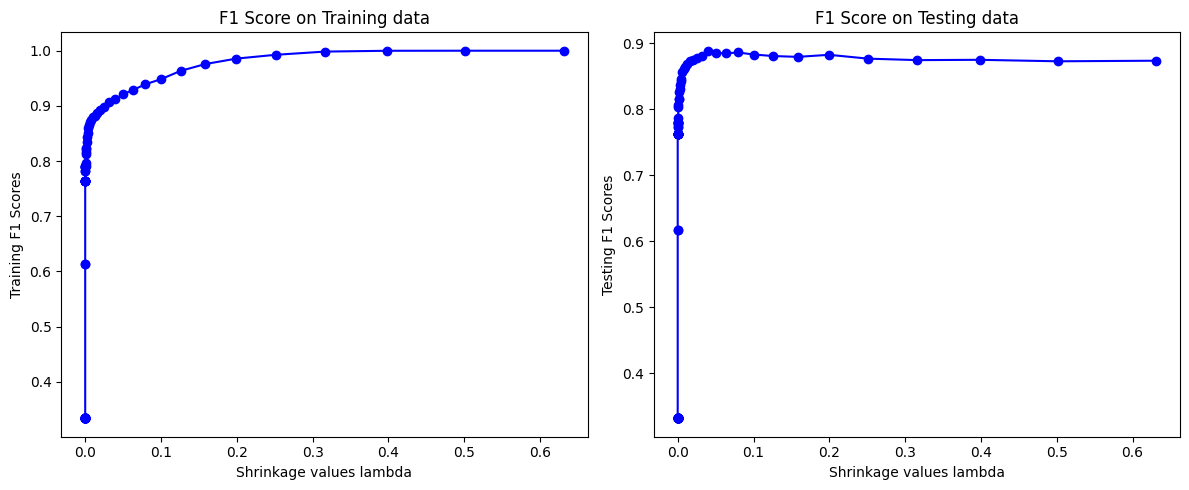

In [35]:
import matplotlib.pyplot as plt

# Set up subplots with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot the Training MSE
axs[0].plot(lambdas, train_scores, 'bo-')
axs[0].set_xlabel("Shrinkage values lambda")
axs[0].set_ylabel("Training F1 Scores")
axs[0].set_title("F1 Score on Training data")

# Plot the Testing MSE
axs[1].plot(lambdas, test_scores, 'bo-')
axs[1].set_xlabel("Shrinkage values lambda")
axs[1].set_ylabel("Testing F1 Scores")
axs[1].set_title("F1 Score on Testing data")

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

In [37]:
best_lambda = lambdas[np.argmax(test_score)]
best_lambda

1e-10

In [50]:
boost_classifier = GradientBoostingClassifier(n_estimators=1000, learning_rate=best_lambda)

# Fit the model to the training data
boost_classifier.fit(data3_smote.drop(columns='Y'), data3_smote['Y'])


GradientBoostingClassifier(learning_rate=1e-10, n_estimators=1000)

### Generating the Kaggle Submission File

In [51]:
final_model = boost_classifier

In [40]:
X_kaggle_test = pd.read_csv('A2_customer_churn_kaggle.csv')

In [41]:
# Add columns
X_kaggle_test1 = add_new_columns(X_kaggle_test)

In [42]:
# Drop columns
columns_to_drop = ['ID', 'Y', 'customer_profile', 'last_lines', 'customer_profile_tokenized']
X_kaggle_test1 = drop_any_existing_columns(X_kaggle_test1, columns = columns_to_drop)

In [43]:
### Dummy variablize
X_kaggle_test1 = pd.get_dummies(X_kaggle_test1, columns = ['gender', 'country'], drop_first=True )

In [44]:
print('Shape of kaggle test: ', X_kaggle_test1.shape)
X_kaggle_test1.head()

Shape of kaggle test:  (2010, 13)


,credit_score,tenure,balance,number_of_products,has_credit_card,is_active_member,salary,age,customer_profile_polarity,last_lines_polarity,gender_male,country_Germany,country_Spain
0,652,4,59486.31,1,1,0,163944.19,48,0.4482,-0.3089,True,False,False
1,714,4,0.00,2,1,1,37605.90,29,0.7845,0.6486,True,False,True
2,733,3,100337.96,3,1,0,48559.19,34,0.4482,-0.3089,True,True,False
3,577,8,79757.21,1,1,0,135650.72,43,0.4482,-0.3089,True,False,True
4,600,2,119755.00,1,1,1,21852.91,30,0.7845,0.6486,True,True,False


In [52]:
y_pred = final_model.predict(X_kaggle_test1)
df_pred = pd.concat([X_kaggle_test['ID'], pd.DataFrame(y_pred,columns=['Y'])], axis = 1)
df_pred.to_csv('kaggle_pred_values.csv',index=False)